# SPAI Comparative Analysis: Original vs Synthetic (First 5,000 Each)\n
\n
This notebook does the following:\n
- selects the first 5,000 images from `archive/original` and the first 5,000 from `archive/synthetic`,\n
- runs SPAI inference on all 10,000 images,\n
- compares score distributions and detection behavior by source category,\n
- logs metrics, tables, and figures to **online** Weights & Biases.

In [1]:
import os
import json
import pathlib
import random
import subprocess
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import wandb

plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.grid"] = True

print("Python:", sys.executable)
print("wandb:", wandb.__version__)

Python: e:\research\spai\spai\.venv\Scripts\python.exe
wandb: 0.25.1


In [2]:
# Paths and configuration
ARCHIVE_DIR = pathlib.Path(r"E:/research/spai/spai/data/dataset/archive")
ORIGINAL_DIR = ARCHIVE_DIR / "original"
SYNTHETIC_DIR = ARCHIVE_DIR / "synthetic"

MODEL_PATH = pathlib.Path(r"E:/research/spai/spai/weights/spai.pth")
CFG_PATH = pathlib.Path(r"E:/research/spai/spai/configs/spai.yaml")
OUTPUT_DIR = pathlib.Path(r"E:/tmp/spai_original_vs_synthetic_eval")

MAX_PER_CATEGORY = 5000
RANDOM_SEED = 42
SCORE_THRESHOLD = 0.5
SUPPORTED_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff", ".webp"}

WANDB_PROJECT = "spai-original-vs-synthetic"
WANDB_ENTITY = None
WANDB_RUN_NAME = "orig-vs-synth-5000-each"

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

assert ORIGINAL_DIR.exists(), f"Original dir not found: {ORIGINAL_DIR}"
assert SYNTHETIC_DIR.exists(), f"Synthetic dir not found: {SYNTHETIC_DIR}"
assert MODEL_PATH.exists(), f"Model file not found: {MODEL_PATH}"
assert CFG_PATH.exists(), f"Config file not found: {CFG_PATH}"

assert (ORIGINAL_DIR / "000001.png").exists(), "Missing original/000001.png"
assert (SYNTHETIC_DIR / "000001.png").exists(), "Missing synthetic/000001.png"

print(ORIGINAL_DIR)
print(SYNTHETIC_DIR)

E:\research\spai\spai\data\dataset\archive\original
E:\research\spai\spai\data\dataset\archive\synthetic


In [3]:
def collect_first_n_images(root: pathlib.Path, n: int):
    imgs = [p for p in root.rglob("*") if p.suffix.lower() in SUPPORTED_EXTENSIONS]
    imgs = sorted(imgs)
    return imgs[: min(n, len(imgs))]

orig_paths = collect_first_n_images(ORIGINAL_DIR, MAX_PER_CATEGORY)
synth_paths = collect_first_n_images(SYNTHETIC_DIR, MAX_PER_CATEGORY)

manifest_orig = pd.DataFrame({"abs_path": [str(p) for p in orig_paths], "source": "original", "expected_label": "real"})
manifest_synth = pd.DataFrame({"abs_path": [str(p) for p in synth_paths], "source": "synthetic", "expected_label": "ai"})
manifest_df = pd.concat([manifest_orig, manifest_synth], ignore_index=True)

manifest_df["image"] = [str(pathlib.Path(p).relative_to(ARCHIVE_DIR)).replace("\\", "/") for p in manifest_df["abs_path"]]
manifest_df.insert(0, "id", np.arange(len(manifest_df), dtype=int))

input_csv = OUTPUT_DIR / "orig_vs_synth_subset.csv"
infer_input_df = manifest_df[["image"]].copy()
infer_input_df["split"] = "test"
infer_input_df["class"] = "1"
infer_input_df.to_csv(input_csv, index=False)

print(manifest_df["source"].value_counts())
print(f"Total selected: {len(manifest_df)}")
manifest_df.head()

source
original     5000
synthetic    5000
Name: count, dtype: int64
Total selected: 10000


,id,abs_path,source,expected_label,image
0,0,E:\research\spai\spai\data\dataset\archive\ori...,original,real,original/000001.png
1,1,E:\research\spai\spai\data\dataset\archive\ori...,original,real,original/000002.png
2,2,E:\research\spai\spai\data\dataset\archive\ori...,original,real,original/000003.png
3,3,E:\research\spai\spai\data\dataset\archive\ori...,original,real,original/000004.png
4,4,E:\research\spai\spai\data\dataset\archive\ori...,original,real,original/000010.png


In [4]:
# Run SPAI inference
cmd = [
    sys.executable,
    "-m",
    "spai",
    "infer",
    "--input", str(input_csv),
    "--input-csv-root-dir", str(ARCHIVE_DIR),
    "--output", str(OUTPUT_DIR),
    "--model", str(MODEL_PATH),
    "--cfg", str(CFG_PATH),
]

print("Running:", " ".join(cmd))
proc = subprocess.run(cmd, capture_output=True, text=True)
print(proc.stdout)
if proc.returncode != 0:
    print(proc.stderr)
    raise RuntimeError(f"SPAI inference failed with code {proc.returncode}")

Running: e:\research\spai\spai\.venv\Scripts\python.exe -m spai infer --input E:\tmp\spai_original_vs_synthetic_eval\orig_vs_synth_subset.csv --input-csv-root-dir E:\research\spai\spai\data\dataset\archive --output E:\tmp\spai_original_vs_synthetic_eval --model E:\research\spai\spai\weights\spai.pth --cfg E:\research\spai\spai\configs\spai.yaml
=> merge config from E:\research\spai\spai\configs\spai.yaml



In [5]:
# Load predictions and compute comparative metrics
result_csv = OUTPUT_DIR / input_csv.name
assert result_csv.exists(), f"Result CSV not found: {result_csv}"

result_df = pd.read_csv(result_csv)
assert "spai" in result_df.columns, "Result CSV missing 'spai'"

result_with_meta = result_df.merge(
    manifest_df[["id", "image", "abs_path", "source", "expected_label"]],
    on="image",
    how="left",
)
result_with_meta["predicted_label"] = np.where(result_with_meta["spai"] > SCORE_THRESHOLD, "ai", "real")
result_with_meta["correct"] = (result_with_meta["predicted_label"] == result_with_meta["expected_label"]).astype(int)

overall_stats = {
    "num_images": int(len(result_with_meta)),
    "spai_mean": float(result_with_meta["spai"].mean()),
    "spai_median": float(result_with_meta["spai"].median()),
    "spai_std": float(result_with_meta["spai"].std(ddof=0)),
    "accuracy_overall": float(result_with_meta["correct"].mean()),
}

by_source = result_with_meta.groupby("source").agg(
    n=("spai", "count"),
    spai_mean=("spai", "mean"),
    spai_median=("spai", "median"),
    pct_pred_ai=("predicted_label", lambda s: (s == "ai").mean() * 100.0),
    pct_correct=("correct", lambda s: s.mean() * 100.0),
).reset_index()

orig_correct = result_with_meta.loc[result_with_meta["source"] == "original", "correct"].mean()
synth_correct = result_with_meta.loc[result_with_meta["source"] == "synthetic", "correct"].mean()
balanced_acc = float((orig_correct + synth_correct) / 2.0)

confusion = pd.crosstab(result_with_meta["expected_label"], result_with_meta["predicted_label"])

print(json.dumps({**overall_stats, "balanced_accuracy": balanced_acc}, indent=2))
display(by_source)
display(confusion)

{
  "num_images": 10000,
  "spai_mean": 0.498258263128024,
  "spai_median": 0.4147002398967743,
  "spai_std": 0.4941216928295263,
  "accuracy_overall": 0.9798,
  "balanced_accuracy": 0.9798
}


,source,n,spai_mean,spai_median,pct_pred_ai,pct_correct
0,original,5000,0.020331,1.962400e-11,1.80,98.20
1,synthetic,5000,0.976185,1.000000e+00,97.76,97.76


predicted_label,ai,real
expected_label,,
ai,4888,112
real,90,4910


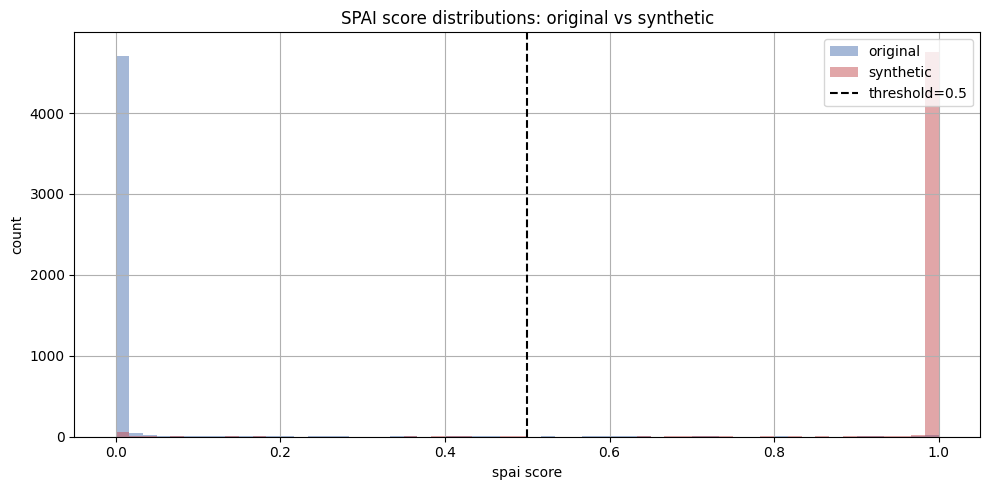

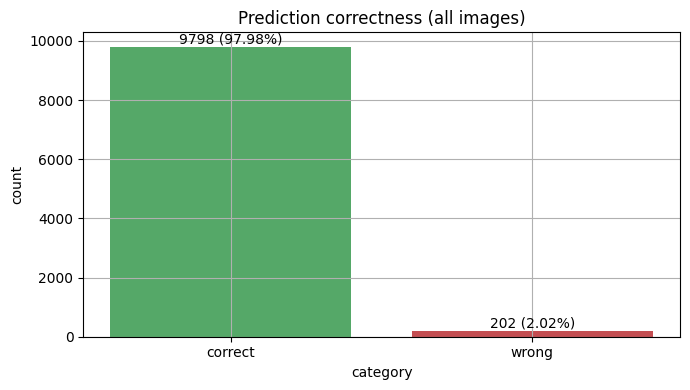

Correct predictions: 9798
Wrong predictions: 202
Accuracy: 97.98%


,prediction_quality,count,percent
0,correct,9798,97.98
1,wrong,202,2.02


W&B online init failed (Failed to read port info after 30.0 seconds.). Falling back to offline mode.


ServicePollForTokenError: Failed to read port info after 30.0 seconds.

In [8]:
# Visualize score distributions and collect misclassifications
fig_hist, ax = plt.subplots(figsize=(10, 5))
for src, color in [("original", "#4C72B0"), ("synthetic", "#C44E52")]:
    vals = result_with_meta.loc[result_with_meta["source"] == src, "spai"]
    ax.hist(vals, bins=60, alpha=0.5, label=src, color=color)
ax.axvline(SCORE_THRESHOLD, color="black", linestyle="--", label=f"threshold={SCORE_THRESHOLD}")
ax.set_title("SPAI score distributions: original vs synthetic")
ax.set_xlabel("spai score")
ax.set_ylabel("count")
ax.legend()
fig_hist.tight_layout()
plt.show()

# Correct vs wrong prediction summary
correct_count = int(result_with_meta["correct"].sum())
wrong_count = int(len(result_with_meta) - correct_count)
accuracy_pct = (correct_count / len(result_with_meta) * 100.0) if len(result_with_meta) else 0.0

correctness_summary = pd.DataFrame(
    {
        "prediction_quality": ["correct", "wrong"],
        "count": [correct_count, wrong_count],
        "percent": [accuracy_pct, 100.0 - accuracy_pct],
    }
)

fig_correctness, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(
    correctness_summary["prediction_quality"],
    correctness_summary["count"],
    color=["#55A868", "#C44E52"],
)
ax.set_title("Prediction correctness (all images)")
ax.set_xlabel("category")
ax.set_ylabel("count")
for bar, pct in zip(bars, correctness_summary["percent"]):
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2, h, f"{int(h)} ({pct:.2f}%)", ha="center", va="bottom")
fig_correctness.tight_layout()
plt.show()

misclassified_df = result_with_meta[result_with_meta["correct"] == 0].copy()

print(f"Correct predictions: {correct_count}")
print(f"Wrong predictions: {wrong_count}")
print(f"Accuracy: {accuracy_pct:.2f}%")
display(correctness_summary)

# Log to W&B: try online first, then fallback to offline to avoid hard failure
api_key = os.getenv("WANDB_API_KEY", "").strip()
if api_key:
    wandb.login(key=api_key, relogin=True)
else:
    wandb.login(relogin=False)

run = None
wandb_mode_used = "online"
try:
    run = wandb.init(
        project=WANDB_PROJECT,
        entity=WANDB_ENTITY,
        name=WANDB_RUN_NAME,
        mode="online",
        config={
            "archive_dir": str(ARCHIVE_DIR),
            "max_per_category": MAX_PER_CATEGORY,
            "score_threshold": SCORE_THRESHOLD,
            "model_path": str(MODEL_PATH),
            "cfg_path": str(CFG_PATH),
        },
    )
except Exception as exc:
    print(f"W&B online init failed ({exc}). Falling back to offline mode.")
    wandb_mode_used = "offline"
    run = wandb.init(
        project=WANDB_PROJECT,
        entity=WANDB_ENTITY,
        name=WANDB_RUN_NAME,
        mode="offline",
        config={
            "archive_dir": str(ARCHIVE_DIR),
            "max_per_category": MAX_PER_CATEGORY,
            "score_threshold": SCORE_THRESHOLD,
            "model_path": str(MODEL_PATH),
            "cfg_path": str(CFG_PATH),
        },
    )

wandb.log({
    "num_images": overall_stats["num_images"],
    "spai_mean": overall_stats["spai_mean"],
    "spai_median": overall_stats["spai_median"],
    "spai_std": overall_stats["spai_std"],
    "accuracy_overall": overall_stats["accuracy_overall"],
    "balanced_accuracy": balanced_acc,
    "num_correct": correct_count,
    "num_wrong": wrong_count,
    "accuracy_pct": accuracy_pct,
})
wandb.log({"spai_all_hist": wandb.Histogram(result_with_meta["spai"].values)})
wandb.log({"fig_spai_hist_by_source": wandb.Image(fig_hist)})
wandb.log({"fig_prediction_correctness": wandb.Image(fig_correctness)})
wandb.log({"by_source_table": wandb.Table(dataframe=by_source)})
wandb.log({"confusion_table": wandb.Table(dataframe=confusion.reset_index())})
wandb.log({"correctness_summary_table": wandb.Table(dataframe=correctness_summary)})
wandb.log({"misclassified_head300": wandb.Table(dataframe=misclassified_df.head(300))})
wandb.finish()

if wandb_mode_used == "online":
    print("W&B online logging complete.")
else:
    print("W&B offline logging complete (online init failed).")

In [9]:
# Save outputs locally
pred_csv = OUTPUT_DIR / "orig_vs_synth_with_predictions.csv"
summary_json = OUTPUT_DIR / "orig_vs_synth_summary.json"
by_source_csv = OUTPUT_DIR / "by_source_summary.csv"
confusion_csv = OUTPUT_DIR / "confusion_matrix.csv"
correctness_csv = OUTPUT_DIR / "prediction_correctness_summary.csv"

result_with_meta.to_csv(pred_csv, index=False)
by_source.to_csv(by_source_csv, index=False)
confusion.to_csv(confusion_csv)
correctness_summary.to_csv(correctness_csv, index=False)

summary_payload = {
    "overall_stats": overall_stats,
    "balanced_accuracy": balanced_acc,
    "correct_count": int(correct_count),
    "wrong_count": int(wrong_count),
    "accuracy_pct": float(accuracy_pct),
    "input_csv": str(input_csv),
    "result_csv": str(result_csv),
    "pred_csv": str(pred_csv),
    "by_source_csv": str(by_source_csv),
    "confusion_csv": str(confusion_csv),
    "correctness_csv": str(correctness_csv),
}
with open(summary_json, "w", encoding="utf-8") as f:
    json.dump(summary_payload, f, indent=2)

fig_hist.savefig(OUTPUT_DIR / "spai_hist_by_source.png", dpi=150, bbox_inches="tight")
fig_correctness.savefig(OUTPUT_DIR / "prediction_correctness.png", dpi=150, bbox_inches="tight")

print("Saved outputs:")
print(pred_csv)
print(by_source_csv)
print(confusion_csv)
print(correctness_csv)
print(summary_json)

Saved outputs:
E:\tmp\spai_original_vs_synthetic_eval\orig_vs_synth_with_predictions.csv
E:\tmp\spai_original_vs_synthetic_eval\by_source_summary.csv
E:\tmp\spai_original_vs_synthetic_eval\confusion_matrix.csv
E:\tmp\spai_original_vs_synthetic_eval\prediction_correctness_summary.csv
E:\tmp\spai_original_vs_synthetic_eval\orig_vs_synth_summary.json
